# Position of a Star

Generate fake mesurment where the true value is normalize to the pic of the gaussian.

In [157]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [158]:
mu = 1
sigma = 0.2

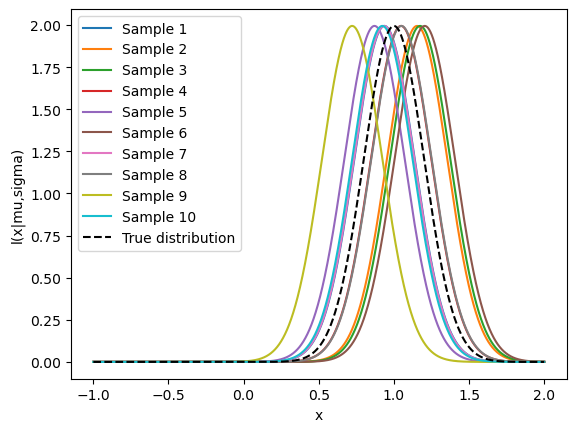

In [159]:
N = 10

sample = norm(mu, sigma).rvs(N)
grid = np.linspace(-1, 2, 10000)

l = np.zeros((N, len(grid)))
for i in range(N):
    l[i] = norm(sample[i], sigma).pdf(grid)
    plt.plot(grid, l[i], label=f'Sample {i+1}')

plt.plot(grid, norm(mu, sigma).pdf(grid), 'k--', label='True distribution')
plt.xlabel('x')
plt.ylabel('l(x|mu,sigma)')
plt.legend()
plt.show()

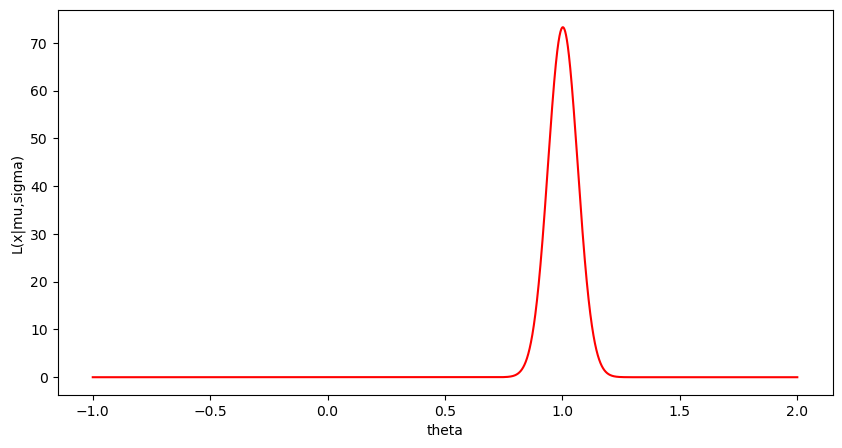

In [160]:
# Total Likelihood 
theta = grid

L = np.ones_like(theta)
for i in range(N):
    L = L * l[i]


plt.figure(figsize=(10,5))
plt.plot(theta, L, 'r-', label='Total likelihood')
plt.xlabel('theta')
plt.ylabel('L(x|mu,sigma)')
plt.show()

In [161]:
MLE = np.argmax(L)
print(f'Maximum Likelihood Estimation: {grid[MLE]}')

Maximum Likelihood Estimation: 1.001800180018002


In [162]:
logL = np.log(L)
MlogLE = np.argmax(logL)
print(f'Maximum (log)Likelihood Estimation: {grid[MlogLE]}')

Maximum (log)Likelihood Estimation: 1.001800180018002


In [163]:
Fisher = - np.diff(logL, 2)
Fisher = Fisher / (theta[1] - theta[0])**2

print(f'Fisher Information: {Fisher[MlogLE]}')

Fisher Information: 249.99999998402473


In [165]:
sigma_MLE = 1 / np.sqrt(Fisher[MlogLE])
print(f'Estimated sigma from Fisher Information: {sigma_MLE}')

Estimated sigma from Fisher Information: 0.06324555320538831


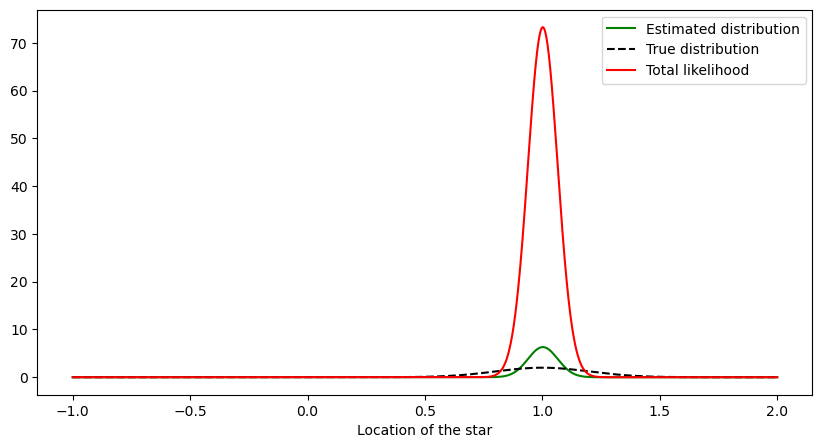

In [168]:
resul = norm(loc=grid[MlogLE], scale=sigma_MLE)

plt.figure(figsize=(10,5))
plt.plot(grid, resul.pdf(grid), 'g-', label='Estimated distribution')
plt.plot(grid, norm(mu, sigma).pdf(grid), 'k--', label='True distribution')
plt.plot(grid, L, 'r-', label='Total likelihood')
plt.xlabel('Location of the star')
plt.legend()
plt.show()